# BSRN Data Retrieval / BSRN 数据获取

This tutorial covers how to browse the BSRN FTP inventory and download station-to-archive files.

本教程涵盖了如何浏览 BSRN FTP 资源目录以及如何下载站点存档文件。

## 1. Setup / 配置

BSRN FTP requires credentials. Obtain them by emailing Amelie Driemel at amelie.Driemel@awi.de.

BSRN FTP 需要凭证。请发邮件至 amelie.Driemel@awi.de 向 Amelie Driemel 申请。

In [ ]:
import os
import bsrn

# Replace with your BSRN FTP credentials
BSRN_USER = os.environ.get("BSRN_USER", "your_username")
BSRN_PASS = os.environ.get("BSRN_PASS", "your_password")
username = BSRN_USER
password = BSRN_PASS

## 2. Check File Inventory / 检查文件目录

Before downloading, you can check which files are available for specific stations. Here we check the inventory for ASP, PAY, QIQ, and TAT stations.

在下载之前，您可以检查特定站点有哪些可用文件。这里我们检查 ASP、PAY、QIQ 和 TAT 站点的目录。

In [2]:
stations = ['ASP', 'PAY', 'QIQ', 'TAT']
inventory = bsrn.io.retrieval.get_bsrn_file_inventory(stations, username, password)

for stn, files in inventory.items():
    print(f"{stn}: {len(files)} files available")
    if files:
        print(f"  First file: {files[0]}")
        print(f"  Last file:  {files[-1]}")

[1/4] Fetching inventory for station ASP...
[2/4] Fetching inventory for station PAY...
[3/4] Fetching inventory for station QIQ...
[4/4] Fetching inventory for station TAT...
ASP: 301 files available
  First file: asp0100.dat.gz
  Last file:  asp1299.dat.gz
PAY: 399 files available
  First file: pay0100.dat.gz
  Last file:  pay1299.dat.gz
QIQ: 14 files available
  First file: qiq0124.dat.gz
  Last file:  qiq1224.dat.gz
TAT: 356 files available
  First file: tat0100.dat.gz
  Last file:  tat1299.dat.gz


## 3. Visualize archive availability / 可视化存档可用性

`plot_bsrn_availability` draws a heatmap of which monthly station-to-archive files exist on the BSRN FTP (years × months) for the stations you choose. It uses the same credentials as above and calls the inventory internally.

`plot_bsrn_availability` 为所选站点绘制 FTP 上各月存档文件是否存在的热图（年份 × 月份）。使用与上文相同的凭据，并在内部查询目录。

Searching BSRN FTP for stations: ASP, PAY, QIQ, TAT...
[1/4] Fetching inventory for station ASP...
[2/4] Fetching inventory for station PAY...
[3/4] Fetching inventory for station QIQ...
[4/4] Fetching inventory for station TAT...


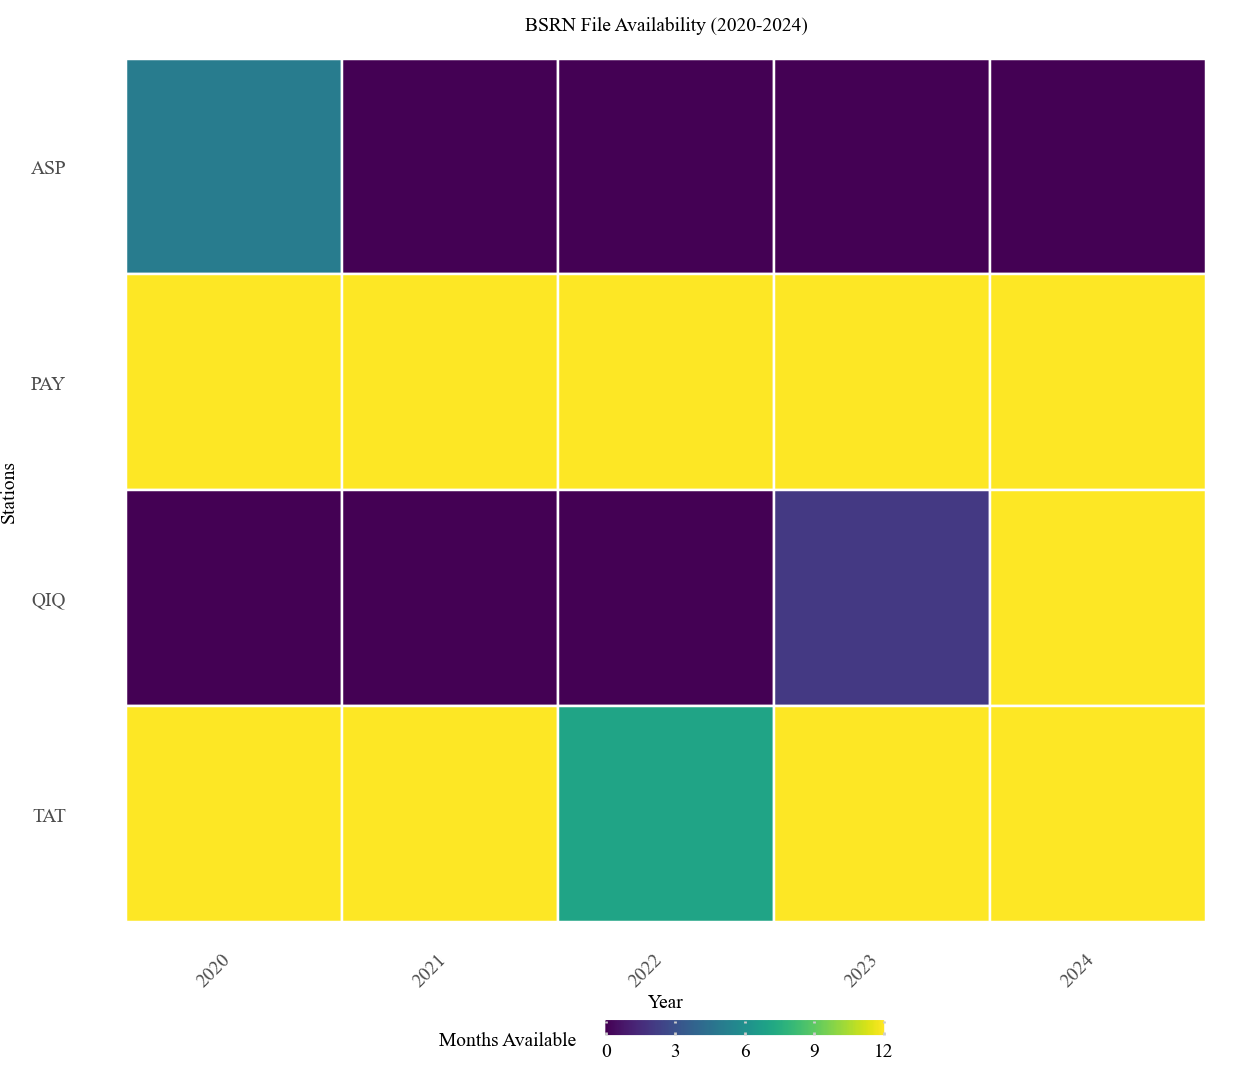

In [3]:
from bsrn.visualization import plot_bsrn_availability

# Heatmap of monthly .dat.gz presence on FTP for the same stations as in §2 (narrow year span for speed).
# §2 中相同站点的月度 .dat.gz 是否在 FTP 上的热图（缩短年份范围以加快运行）。
fig = plot_bsrn_availability(
    stations=stations,
    username=username,
    password=password,
    start_year=2020,
    end_year=2024,
    output_file=None,  # e.g. "qiq_availability.png" to save next to the notebook
)
fig

## 4. Download QIQ 2024 Data / 下载 QIQ 2024 数据

Now let's download all 12 monthly files for the QIQ station for the year 2024.

现在让我们下载 QIQ 站点 2024 年全年的 12 个月度文件。

In [4]:
OUTPUT_DIR = os.path.abspath("../../../data/QIQ")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Construct filenames for 2024 (qiq0124.dat.gz to qiq1224.dat.gz)
filenames = [f"qiq{m:02d}24.dat.gz" for m in range(1, 13)]

print(f"Downloading to {OUTPUT_DIR}")
print("-" * 50)

paths = bsrn.io.retrieval.download_bsrn_files(
    filenames=filenames,
    local_dir=OUTPUT_DIR,
    username=username,
    password=password
)

for fn, p in zip(filenames, paths):
    status = "OK" if p else "FAILED"
    print(f"  {fn}: {status}")

ok = sum(1 for p in paths if p)
print("-" * 50)
print(f"Done. {ok}/{len(paths)} files downloaded.")

--------------------------------------------------
  qiq0124.dat.gz: OK
  qiq0224.dat.gz: OK
  qiq0324.dat.gz: OK
  qiq0424.dat.gz: OK
  qiq0524.dat.gz: OK
  qiq0624.dat.gz: OK
  qiq0724.dat.gz: OK
  qiq0824.dat.gz: OK
  qiq0924.dat.gz: OK
  qiq1024.dat.gz: OK
  qiq1124.dat.gz: OK
  qiq1224.dat.gz: OK
--------------------------------------------------
Done. 12/12 files downloaded.
